# Berry curvature, Chern numbers and Z2 invariants

The Berry curvature is the field strength of the geometric connection an occupied band
carries through the Brillouin zone, and its integral is an integer:

$$\Omega_{n}(\mathbf k) = i\,\nabla_{\mathbf k} \times
   \langle u_{n\mathbf k}|\nabla_{\mathbf k} u_{n\mathbf k}\rangle,
\qquad
C = \frac{1}{2\pi}\int_{\rm BZ} \Omega(\mathbf k)\; d^2k \in \mathbb{Z}$$

That integer is what makes a quantum Hall conductance quantised and what distinguishes a
topological insulator from an ordinary one: no continuous deformation of the Hamiltonian
can change it without closing the gap.

Everything here is built from the overlap of the occupied manifolds at neighbouring
k-points, $M^{(\mathbf k,\mathbf k')}_{mn} = \langle u_{m\mathbf k}|\hat S|u_{n\mathbf k'}
\rangle$, in the lattice form of Fukui, Hatsugai and Suzuki:

$$C = \frac{1}{2\pi}\sum_{\square}
  \arg \Big[
   \det M^{(\mathbf k,\mathbf k+\mathbf b_1)}\;
   \det M^{(\mathbf k+\mathbf b_1,\mathbf k+\mathbf b_1+\mathbf b_2)}\;
   \det M^{(\cdots)}\;\det M^{(\cdots)} \Big]$$

A sum of plaquette phases, each taken in $(-\pi,\pi]$. A determinant of overlaps does not
care how the eigensolver mixed a degenerate multiplet, and the sum is an **exact integer on
any mesh** where a Riemann sum of the pointwise curvature is not.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.system.symmetry import find_symmetries
from pypresso.topology import (ModelSource, chern_number, plane_mesh, trim_points,
                               z2_invariant, z2_invariant_3d)
from pypresso.topology.parity import inversion_centre, parity_eigenvalues
from pypresso.workflows.topology import DFTSource, run_berry_curvature

REPO = Path.cwd().parent
PSEUDO, CASES = REPO / "tests" / "data" / "pseudo", REPO / "tests" / "data" / "qe"
sys.path.insert(0, str(REPO))
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

silicon = Calculator.from_file(CASES / "si2-us.in", pseudo_dir=PSEUDO,
                               announce=False, conv_thr=1e-10)
system, pseudos = silicon.system, silicon.pseudos
si = silicon.get_scf()
source = DFTSource(system=system, pseudos=pseudos, density=si.density, nocc=4)

# The zone-edge wrap, measured: k = 0.4 -> 0.5 directly, and the same step taken as
# 0.4 -> -0.5 + b1, with and without the Miller-index shift that makes them the same.
direct = source.states(np.array([[0.4, 0, 0], [0.5, 0, 0]]))
through = source.states(np.array([[0.4, 0, 0], [-0.5, 0, 0]]))
print("|det M|  k = 0.4 -> 0.5   directly     %.10f"
      % abs(np.linalg.det(np.asarray(direct.overlap(0, 1, None)))))
print("|det M|  k = 0.4 -> -0.5  through b1   %.10f"
      % abs(np.linalg.det(np.asarray(through.overlap(0, 1, [1, 0, 0])))))
print("|det M|  k = 0.4 -> -0.5  no wrap      %.10f   <- wrong, and smooth"
      % abs(np.linalg.det(np.asarray(through.overlap(0, 1, None)))))

|det M|  k = 0.4 -> 0.5   directly     0.9904014550
|det M|  k = 0.4 -> -0.5  through b1   0.9904014650
|det M|  k = 0.4 -> -0.5  no wrap      0.0091756299   <- wrong, and smooth


## The Chern number is an integer, not nearly one

The Haldane model, where the answer is known. The lattice sum returns 1 to fifteen decimals
on a 6x6 mesh; the Kubo route, which gives a smooth pointwise $\Omega(\mathbf k)$ and sums
it as an ordinary Riemann sum, is still 1e-3 away on 24x24. Both are available, one for the
invariant and one for the picture.

    mesh            C (lattice)   max plaquette phase     C (kubo)


  6x6        -1.000000000000000                0.6901    -1.008575


 12x12       -1.000000000000000                0.1983    -1.000017


 24x24       -1.000000000000000                0.0532    -1.000000


trivial (mass 1.5), 12x12:  C = -0.000000000000000


Text(0.5, 0.98, 'Haldane model: the same curvature, two constructions')

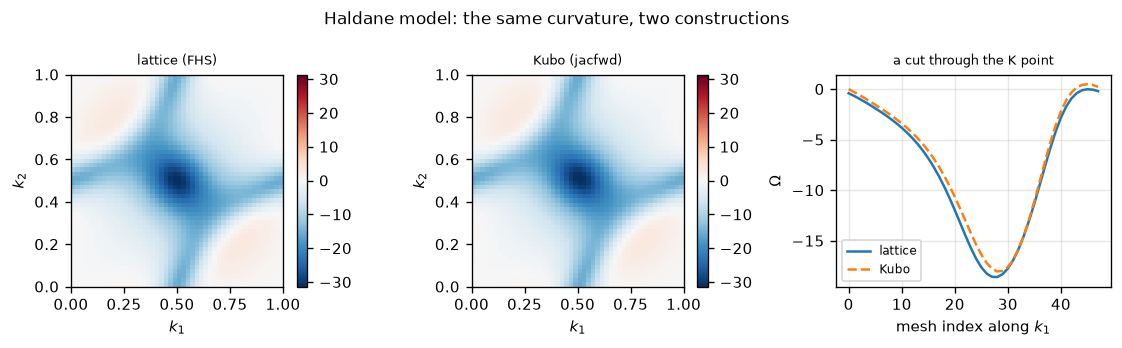

In [2]:
from tests.models import haldane, kane_mele, kane_mele_critical_mass

topological = ModelSource(hamiltonian=haldane(t2=0.2, mass=0.0), nocc=1)
trivial = ModelSource(hamiltonian=haldane(t2=0.2, mass=1.5), nocc=1)

print("%8s %22s %21s %12s" % ("mesh", "C (lattice)", "max plaquette phase", "C (kubo)"))
for n in (6, 12, 24):
    lattice = chern_number(topological, shape=(n, n))
    kubo = chern_number(topological, shape=(n, n), method="kubo", nocc=1)
    print("%3dx%-4d %22.15f %21.4f %12.6f"
          % (n, n, lattice.chern_number, lattice.max_flux, kubo.chern_number))
print("trivial (mass 1.5), 12x12:  C = %.15f"
      % chern_number(trivial, shape=(12, 12)).chern_number)

lattice = chern_number(topological, shape=(48, 48))
kubo = chern_number(topological, shape=(48, 48), method="kubo", nocc=1)
scale = np.max(np.abs(lattice.curvature))
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.9))
for ax, field, title in ((axes[0], lattice.curvature, "lattice (FHS)"),
                         (axes[1], kubo.curvature, "Kubo (jacfwd)")):
    image = ax.imshow(field.T, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu_r",
                      vmin=-scale, vmax=scale)
    ax.set_title(title, fontsize=8); ax.set_xlabel("$k_1$"); ax.set_ylabel("$k_2$")
    ax.grid(False); fig.colorbar(image, ax=ax, fraction=0.046)
axes[2].plot(lattice.curvature[:, 16], label="lattice")
axes[2].plot(kubo.curvature[:, 16], "--", label="Kubo")
axes[2].set_title("a cut through the K point", fontsize=8)
axes[2].set_xlabel("mesh index along $k_1$"); axes[2].set_ylabel(r"$\Omega$")
axes[2].legend(fontsize=7)
fig.suptitle("Haldane model: the same curvature, two constructions", fontsize=10)

## Z2 by the flow of Wannier charge centres

With time reversal the Chern number vanishes and what is left is a $\mathbb{Z}_2$
invariant. Pump one half of the zone and watch the Wannier centres of the occupied bands:
in the topological phase they switch partners, so any horizontal reference line is crossed
an odd number of times, and in the trivial phase they return to themselves. The number to
read before believing the integer is how far the largest-gap reference line moves in one
pumping step: if the centres move faster than the mesh resolves, the crossing count is not
trustworthy.

mass = 0.1299 = 0.5 m_c   ->   z2 = 1


mass = 0.3897 = 1.5 m_c   ->   z2 = 0


Text(0.5, 0.98, 'Kane-Mele: the centres switch partners only in the topological phase')

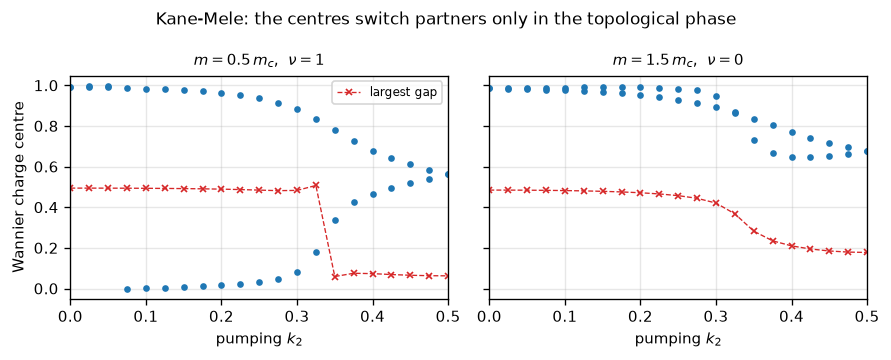

In [3]:
soc = 0.05
critical = kane_mele_critical_mass(soc)
flows = {}
for factor in (0.5, 1.5):
    flows[factor] = z2_invariant(
        ModelSource(hamiltonian=kane_mele(soc=soc, mass=factor * critical), nocc=2),
        nloop=41, npump=21)
    print("mass = %.4f = %g m_c   ->   z2 = %d"
          % (factor * critical, factor, flows[factor].z2))

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0), sharey=True)
for ax, (factor, flow) in zip(axes, sorted(flows.items())):
    for branch in range(flow.centers.shape[1]):
        ax.plot(flow.pump, flow.centers_fractional[:, branch], "o", ms=3, color="C0")
    ax.plot(flow.pump, (flow.gap_center / (2 * np.pi)) % 1.0, "x--", ms=4, lw=0.8,
            color="C3", label="largest gap")
    ax.set_title(r"$m = %g\,m_c$,  $\nu = %d$" % (factor, flow.z2), fontsize=9)
    ax.set_xlabel("pumping $k_2$"); ax.set_xlim(0, 0.5)
axes[0].set_ylabel("Wannier charge centre"); axes[0].legend(fontsize=7)
fig.suptitle("Kane-Mele: the centres switch partners only in the topological phase",
             fontsize=10)

## A second, independent route: parities at the TRIM

Where the crystal has an inversion centre, Fu and Kane's product of parity eigenvalues over
the time-reversal-invariant momenta gives the same invariant from **eight diagonalisations
and no mesh at all**. Running both wherever both apply is the check: first on a 3D lattice
Dirac model whose four phases are known in closed form, then on silicon's real Kohn-Sham
states.

In [4]:
from tests.models import (WILSON_FERMION_INVERSION, wilson_fermion_3d,
                          wilson_fermion_indices)

print("%6s %14s %10s %10s" % ("m", "closed form", "parity", "Wilson"))
for mass in (-4.0, -2.0, 0.0, 2.0):
    model = ModelSource(hamiltonian=wilson_fermion_3d(mass), nocc=2,
                        inversion=WILSON_FERMION_INVERSION)
    exact = wilson_fermion_indices(mass)
    print("%6.1f %14s %10s %10s"
          % (mass, "(%d; %s)" % (exact[0], "".join(str(x) for x in exact[1])),
             z2_invariant_3d(model, method="parity"),
             z2_invariant_3d(model, method="wilson", nloop=16, npump=9)))

centre = inversion_centre(find_symmetries(system.cell, system.structure))
points = trim_points(3)
si_trim = source.states(points, keep_projectors=True)
product = 1
print("\nsilicon, on Kohn-Sham states:")
for index, point in enumerate(points):
    matrix = np.asarray(si_trim.parity_matrix(index, centre))
    values = parity_eigenvalues(matrix)
    product *= int(np.prod(values))
    print("  %16s  parities %s  delta = %+d"
          % ("(" + ", ".join("%.1f" % x for x in point) + ")",
             values.astype(int), int(np.prod(values))))
print("  product over the eight TRIM = %+d   ->   nu0 = %d"
      % (product, 0 if product == 1 else 1))

curvature = silicon.get_berry_curvature(shape=(6, 6), nocc=4)
print("\nsilicon's Berry curvature (6x6 plane at k3 = 0): Chern number %.1e, "
      "largest plaquette phase %.1e"
      % (curvature.chern_number, curvature.max_flux))

     m    closed form     parity     Wilson


  -4.0       (0; 000)   (0; 000)   (0; 000)


  -2.0       (1; 000)   (1; 000)   (1; 000)


   0.0       (0; 111)   (0; 111)   (0; 111)


   2.0       (1; 111)   (1; 111)   (1; 111)



silicon, on Kohn-Sham states:
   (0.0, 0.0, 0.0)  parities [1 1 1 1]  delta = +1
   (0.0, 0.0, 0.5)  parities [-1 -1 -1  1]  delta = -1
   (0.0, 0.5, 0.0)  parities [-1 -1 -1  1]  delta = -1
   (0.0, 0.5, 0.5)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.0, 0.0)  parities [-1 -1 -1  1]  delta = -1
   (0.5, 0.0, 0.5)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.5, 0.0)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.5, 0.5)  parities [-1  1  1  1]  delta = -1
  product over the eight TRIM = +1   ->   nu0 = 0



silicon's Berry curvature (6x6 plane at k3 = 0): Chern number 2.7e-17, largest plaquette phase 8.7e-08


## The curvature as a map, not as an integer

Everything above reads the curvature as a *flux*, which is what makes it an exact integer.
The other thing anyone wants from $\Omega(\mathbf k)$ is the **map**: where in the zone the
curvature lives, which is what an anomalous-Hall or a valley-Hall argument is made of. That
comes from the Kubo expression,

$$\Omega_n^{12}(\mathbf k) = -2\,\mathrm{Im} \sum_{m \neq n}
\frac{A^{1}_{nm} A^{2}_{mn}}{(\varepsilon_n - \varepsilon_m)^2},
\qquad A^{a}_{nm} = \langle \psi_n |\, \partial_{k_a} H - \varepsilon_n \partial_{k_a} S \,| \psi_m \rangle .$$

**AlAs is the cell to show it on.** It has time-reversal symmetry but no inversion centre,
so $\Omega(\mathbf k)$ is nonzero pointwise while the Chern number is zero: the map has
structure and the integer does not.

AlAs     max|Omega|          1.3605
         truncation of the sum over empty states  2.0 %
         Chern, FHS         2.51e-15   <- exact by construction
         Chern, Kubo sum    1.18e-05   <- a Riemann sum, near zero and not zero
silicon  max|Omega|         3.29e-06   <- inversion + T, vanishes pointwise


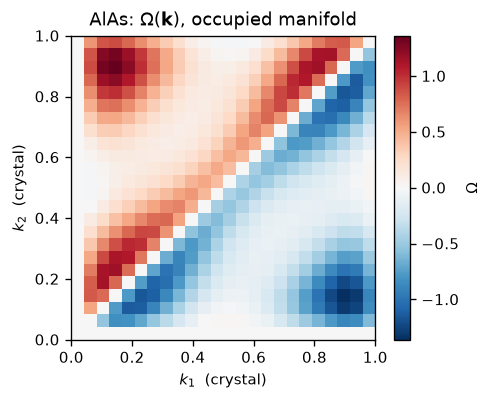

In [5]:
alas = Calculator.from_file(CASES / "alas-raman.in", pseudo_dir=PSEUDO,
                            announce=False, conv_thr=1e-10)
al = alas.get_scf()

kubo = run_berry_curvature(alas.system, alas.pseudos, al.density, shape=(24, 24),
                           nocc=4, nbnd=20, method="kubo")
fhs = run_berry_curvature(alas.system, alas.pseudos, al.density, shape=(24, 24),
                          nocc=4, method="fhs")
omega = np.asarray(kubo.curvature)

# Silicon has an inversion centre as well, which forces the curvature to vanish
# *pointwise* -- a stronger statement than the Chern number being zero. The
# norm-conserving cell, because the Kubo route refuses an augmented dataset.
si_nc = Calculator.from_file(CASES / "si-epsilon.in", pseudo_dir=PSEUDO,
                             announce=False, conv_thr=1e-10)
si_kubo = run_berry_curvature(si_nc.system, si_nc.pseudos, si_nc.get_scf().density,
                              shape=(8, 8), nocc=4, nbnd=16, method="kubo")

print("AlAs     max|Omega|        %8.4f" % abs(omega).max())
print("         truncation of the sum over empty states  %.1f %%"
      % (100 * kubo.truncation))
print("         Chern, FHS        %9.2e   <- exact by construction"
      % np.asarray(fhs.flux).sum())
print("         Chern, Kubo sum   %9.2e   <- a Riemann sum, near zero and not zero"
      % (omega.sum() / omega.size))
print("silicon  max|Omega|        %9.2e   <- inversion + T, vanishes pointwise"
      % abs(np.asarray(si_kubo.curvature)).max())

fig, ax = plt.subplots(figsize=(4.2, 3.4))
image = ax.imshow(omega.T, origin="lower", extent=(0, 1, 0, 1),
                  cmap="RdBu_r", vmin=-abs(omega).max(), vmax=abs(omega).max())
ax.set_xlabel("$k_1$  (crystal)")
ax.set_ylabel("$k_2$  (crystal)")
ax.set_title(r"AlAs: $\Omega(\mathbf{k})$, occupied manifold")
ax.grid(False)
fig.colorbar(image, ax=ax, label=r"$\Omega$")
plt.show()

The map is what the Kubo route is for and the integer is what it is *not* for. Its
denominator $(\varepsilon_n-\varepsilon_m)^{-2}$ blows up at a degeneracy and its
Brillouin-zone sum is an ordinary Riemann sum, where the lattice flux above is zero to
$10^{-15}$ because a determinant of overlaps cannot be anything else. Two things it reports
rather than hides: how much of the sum over empty states is missing, tightened by raising
`nbnd`, and that a per-band curvature is meaningful only for a non-degenerate band, since
inside a degenerate multiplet only the sum over the members is defined. This route is
available for norm-conserving datasets; the lattice flux carries the augmentation charge
correctly and runs on all three kinds.

Silicon is inversion-symmetric *and* time-reversal-symmetric, so its curvature vanishes
pointwise rather than only on average, which the plane above shows, and its parity product
makes it the trivial insulator it is.

## Bismuthene, and what to do when the two routes disagree

The hardest case here, two-component spinors with a fully relativistic ultrasoft dataset
under PBE, is quoted rather than run, since it peaks at 7.8 GB. Measured on
`bismuthene-soc-small.in`:

```
SCF, 7 irreducible k-points          -295.610317532 Ry     281 s   4.24 GB
<u_m|S|u_n> - delta_mn                4.4e-15   (30 spinor bands)
parity, 4 TRIM: nu = 0                delta = -1 at all four     133 s
Wilson, 12 x 7 mesh: z2 = 1           gap_step = 0.197           786 s   4.53 GB
```

The two routes disagree, which is the interesting outcome rather than an embarrassing one.
The parity route has no mesh: four diagonalisations at exact points, with parity
eigenvalues coming out $\pm1$ to 1e-6. The Wilson route's own diagnostic says its mesh is
too coarse, the reference line moving a fifth of the way round the circle in a single
pumping step. Where they disagree like this, the parity answer is the one to take.

---
The tests behind this notebook: `tests/regression/test_topology.py`,
`tests/unit/test_topology_*.py`.